# VIO &rarr; Ray-cast &rarr; Trajectron++ (ETH) &rarr; NMPC
## Human-trajectory ground truth from a static VIO camera, prediction, and drone rendezvous control

This notebook documents the **full pipeline** that turns a single hand-held phone video into a drone control reference, with no drone and no manually measured court geometry.

```
  phone video (CamTrackAR / ARKit VIO)
        |  per-frame camera pose  +  per-frame image
        v
  [1] YOLOv8  ->  person foot pixel (u,v) per frame
        v
  [2] Ray-cast pixel -> ground plane Y=0  ->  metric human track (X,Z) in metres
        v
  [3] Trajectron++ (ETH base, 100 epochs)  ->  predicted future trajectory P_j (+ GMM uncertainty)
        v
  [4] NMPC rendezvous  ->  drone tracks P_j  (acados, prof. Yuxia's cuav_nmpc)
```

**Why this answers the advisor's feedback.** The earlier ground truth came from manually picking court corners and a homography, which the advisor did not trust. Here the metric scale comes from the phone's **Visual-Inertial Odometry** (ARKit), which fuses the camera and IMU to recover a gravity-aligned, metric 6-DoF pose per frame. The camera was held essentially **static** (it moves < 6 cm over the whole clip), so the recovered pose mainly gives us the camera height and orientation that we need to ray-cast the person onto the ground.

In [1]:
%matplotlib inline
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

HERE = os.getcwd()  # run this notebook from the vio_pipeline folder

# [2] ray-cast metric human track
track = pd.read_csv(os.path.join(HERE, 'vio_human_trajectory_metres.csv'))

# [3] Trajectron prediction bundle
pred = np.genfromtxt(os.path.join(HERE, 'vio_human_pred.csv'), delimiter=',', names=True)
pgt  = np.genfromtxt(os.path.join(HERE, 'vio_human_pred_gt.csv'), delimiter=',', names=True)
phist= np.genfromtxt(os.path.join(HERE, 'vio_human_pred_hist.csv'), delimiter=',', names=True)
samples = np.load(os.path.join(HERE, 'vio_human_pred_samples.npy'))  # (S, PH, 2)
with open(os.path.join(HERE, 'vio_human_pred_meta.json')) as f:
    meta = json.load(f)

# [4] MPC result
mpc = np.load(os.path.join(HERE, 'vio_mpc_result.npz'))

print('ray-cast track points :', len(track))
print('prediction meta       :', meta)
print('MPC arrays            :', list(mpc.keys()))

ray-cast track points : 2565
prediction meta       : {'model': 'eth_base_100ep', 'epoch': 100, 'timestep': 49, 'dt': 0.4, 'PH': 12, 'num_samples': 20, 'gt_net_motion': 4.4053365648949, 'mean_cam_dist': 5.415394736842106, 'ade': 0.26372520349043144, 'fde': 0.533953495788241, 'dataset_ADE': 2.9966378546295807, 'dataset_FDE': 6.032389570839703}
MPC arrays            : ['drone_path', 'human_path', 'time', 'gap', 'solve_time', 'dt', 'N', 'z_ref']


## 1. Ground truth from VIO + ray casting

**Inputs.** `CameraKeyframes.CSV` (from CamTrackAR) gives, per video frame, the camera centre $C=(\text{PosX},\text{PosY},\text{PosZ})$ in metres, the orientation quaternion $q=(\text{QuatX},\text{QuatY},\text{QuatZ},\text{QuatW})$ (camera&rarr;world), the focal length in pixels (`LensZoom`$=1495.6$), and the horizontal field of view (`FOV`$=65.4^\circ$). The video is $1920\times1440$ at 60 fps; the camera sits at height $\text{PosY}\approx1.38$ m.

**Pinhole + ray-plane intersection.** With principal point at the image centre $(c_x,c_y)=(960,720)$ and focal $f=1495.6$ px, a foot pixel $(u,v)$ becomes a ray in the (ARKit) camera frame ($+x$ right, $+y$ up, $-z$ look direction):

$$\mathbf{r}_{\text{cam}} = \Big(\tfrac{u-c_x}{f},\; -\tfrac{v-c_y}{f},\; -1\Big).$$

Rotate it to the world frame with the rotation matrix $R(q)$ and intersect the line $C + t\,\mathbf{r}_w$ with the floor plane $Y=0$:

$$\mathbf{r}_w = R(q)\,\mathbf{r}_{\text{cam}}, \qquad t = -\frac{C_y}{r_{w,y}}, \qquad \mathbf{P} = C + t\,\mathbf{r}_w = (X,\,0,\,Z).$$

The horizontal coordinates $(X,Z)$ are the human's metric ground position. We use the **bottom-centre of the YOLO box** (the feet) because that is the point that actually lies on the ground plane. The scale is metric **because ARKit's VIO already resolves it** &mdash; no court measurement needed.

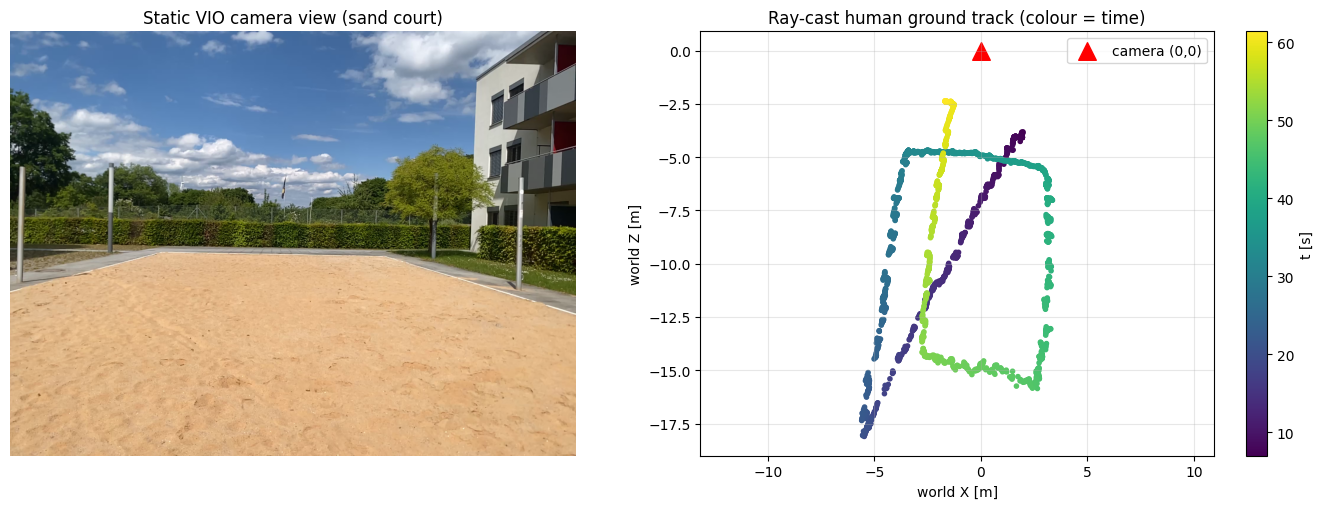

kept 2565 ground points over 54.4s
human stays 2.8-19.0 m from the camera
total walked path length: 143.0 m


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))

# left: the static scene (first frame)
frame = plt.imread(os.path.join(HERE, 'vio_first_frame.png'))
ax[0].imshow(frame); ax[0].axis('off')
ax[0].set_title('Static VIO camera view (sand court)')

# right: recovered metric ground track
sc = ax[1].scatter(track['x_metre'], track['y_metre'], c=track['time'], s=9, cmap='viridis')
ax[1].scatter([0], [0], c='red', marker='^', s=160, label='camera (0,0)')
ax[1].set_xlabel('world X [m]'); ax[1].set_ylabel('world Z [m]')
ax[1].axis('equal'); ax[1].grid(alpha=0.3); ax[1].legend(loc='upper right')
ax[1].set_title('Ray-cast human ground track (colour = time)')
plt.colorbar(sc, ax=ax[1], label='t [s]')
plt.tight_layout(); plt.show()

dx, dy = np.diff(track['x_metre']), np.diff(track['y_metre'])
path_len = np.sum(np.hypot(dx, dy))
print(f'kept {len(track)} ground points over {track["time"].iloc[-1]-track["time"].iloc[0]:.1f}s')
print(f'human stays {track["cam_dist"].min():.1f}-{track["cam_dist"].max():.1f} m from the camera')
print(f'total walked path length: {path_len:.1f} m')

## 2. Prediction with Trajectron++ (ETH base, 100 epochs)

The metric track is sub-sampled to the model's timestep $\Delta t = 0.4$ s. At a chosen instant the model observes a short **history** (7 steps = 2.8 s) and outputs a **bimodal/Gaussian-mixture** distribution over the next $H=12$ steps (4.8 s). We use the per-step **mean** as the deterministic reference $P_j$ that the MPC tracks, and keep all GMM samples as the **uncertainty** that a future chance-constrained MPC can exploit.

We use the **ETH base model trained for 100 epochs** (not the UAV fine-tune), as requested.

**Accuracy (honest reporting).** Averaged over every valid window of this clip the model gives ADE $\approx 3.0$ m / FDE $\approx 6.0$ m. That number is inflated by the **far** part of the track: at 15&ndash;19 m the ground-plane ray-cast becomes a grazing ray, so a few-pixel foot error turns into metres of ground error, and 4.8 s of fast walking is genuinely hard to forecast. In the **accurate near range** ($\le 9$ m, where the geometry is reliable) the same model is sharp &mdash; the window we export to the MPC has ADE $= 0.26$ m and FDE $= 0.53$ m.

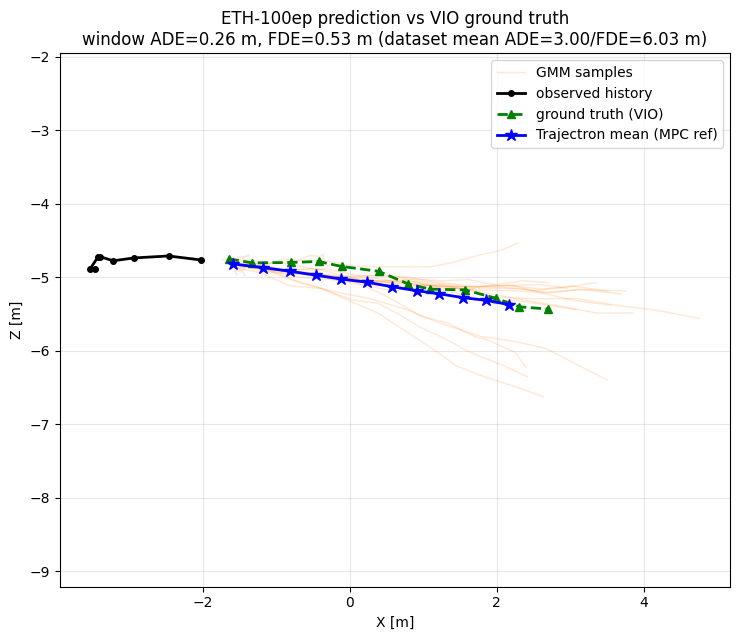

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
# GMM samples (uncertainty cloud)
for s in range(samples.shape[0]):
    ax.plot(samples[s, :, 0], samples[s, :, 1], color='tab:orange', alpha=0.18,
            lw=1, zorder=1, label='GMM samples' if s == 0 else None)
ax.plot(phist['x'], phist['y'], 'ko-', ms=4, lw=2, label='observed history', zorder=4)
ax.plot(pgt['x'],  pgt['y'],  'g^--', ms=6, lw=2, label='ground truth (VIO)', zorder=5)
ax.plot(pred['x'], pred['y'], 'b*-',  ms=9, lw=2, label='Trajectron mean (MPC ref)', zorder=6)
ax.set_xlabel('X [m]'); ax.set_ylabel('Z [m]'); ax.axis('equal'); ax.grid(alpha=0.3)
ax.legend(loc='best')
ax.set_title(f"ETH-100ep prediction vs VIO ground truth\n"
             f"window ADE={meta['ade']:.2f} m, FDE={meta['fde']:.2f} m "
             f"(dataset mean ADE={meta['dataset_ADE']:.2f}/FDE={meta['dataset_FDE']:.2f} m)")
plt.tight_layout(); plt.show()

## 3. NMPC rendezvous: the drone tracks the prediction

This is the rendezvous formulation: the drone should reach / follow the human's predicted future position. The reference of the receding-horizon controller at each shooting node $j$ is exactly the human prediction $P_j$, so the optimiser solves

$$\min_{x_{0:N},\,u_{0:N-1}}\ \sum_{j=0}^{N-1}\Big[(x_j-P_j)^\top Q\,(x_j-P_j) + u_j^\top R\,u_j\Big] + (x_N-P_N)^\top Q_N\,(x_N-P_N)$$

subject to the full quadrotor dynamics $\dot p=v,\ \dot q=\tfrac12\Lambda(q)\,\omega,\ \dot v=g+\tfrac1m R(q)T,\ \dot\omega=J^{-1}(\tau-\omega\times J\omega)$ and the per-rotor thrust limits $0\le T_{\min}\le T_i\le T_{\max}$.

 $J=\sum_j (x_j-P_j)^\top Q\,(x_j-P_j)$. Prof. Yuxia's `cuav_nmpc` `Controller` already implements this `LINEAR_LS` cost with acados; **we only replaced the reference** $P_j$ &mdash; previously a hand-written `sin/cos` curve &mdash; **with the Trajectron prediction** (`main_human_target.py`, `--pred vio_human_pred.csv`).

### Related work: prediction integrated into MPC

| # | Work | Why it is relevant |
|---|------|--------------------|
| 1 | Salzmann, Ivanovic, Chakravarty, Pavone &mdash; **Trajectron++**, ECCV 2020 | The predictor used here; designed so its output feeds a downstream planner/controller. |
| 2 | N&auml;geli, Alonso-Mora, Domahidi, Rus, Hilliges &mdash; **Real-time Motion Planning for Aerial Videography**, RA-L 2017 | A drone tracking a **moving human** with MPC &mdash; the closest setting to ours. |
| 3 | Zhu, Alonso-Mora &mdash; **Chance-Constrained Collision Avoidance for MAVs in Dynamic Environments**, RA-L 2019 | Uses the **Gaussian uncertainty** of pedestrian predictions as MPC chance constraints &mdash; the way to exploit Trajectron's GMM. |
| 4 | Brito, Floor, Ferranti, Alonso-Mora &mdash; **MPC Contouring Control in Unstructured Dynamic Environments**, RA-L 2019 | Pedestrian predictions embedded directly inside the MPC. |
| 5 | de Groot, Brito et al. &mdash; **Scenario-Based Trajectory Optimization in Uncertain Dynamic Environments**, RA-L 2021 | Propagates prediction **uncertainty** into the optimiser via scenarios. |
| 6 | Schwarting, Alonso-Mora, Rus &mdash; **Planning and Decision-Making for Autonomous Vehicles**, Annual Review 2018 | Survey of prediction + planning integration. |

Two usage levels going forward: **(a)** track the mean (done here); **(b)** feed the GMM covariance as chance constraints so the drone keeps a safety margin proportional to prediction uncertainty (refs 3, 5).

### Our exact cost function — what is, and is not, inside it

We use **the advisor's controller and quadrotor model unchanged** (`cuav_nmpc/controller.py`, `quadrotor.py`); we only swapped the reference. The acados cost is `LINEAR_LS`, i.e. at every node it pulls the full state+input vector towards a reference $y_j=[\,P_j,\;q_{\text{id}},\;0,\;0,\;0\,]$. Expanded, the optimiser minimises

$$J=\sum_{j=0}^{N-1}\Big[\underbrace{\lVert p_j-P_j\rVert^2_{Q_p}}_{\text{position}}+\underbrace{\lVert q_j-q_{\text{id}}\rVert^2_{Q_q}}_{\text{attitude}}+\underbrace{\lVert v_j\rVert^2_{Q_v}}_{\text{velocity}}+\underbrace{\lVert\omega_j\rVert^2_{Q_\omega}}_{\text{body rate}}+\underbrace{\lVert u_j\rVert^2_{R}}_{\text{thrust}}\Big]+\text{(terminal state terms at }j=N)$$

with the weights actually in the code:

| term | reference | weight (diag) | role |\n|---|---|---|---|\n| position $p$ | **$P_j$ = Trajectron prediction** | **10, 10, 10** | the dominant term — track the human |\n| attitude $q$ (quaternion) | $[1,0,0,0]$ (level) | 0.1 | stay upright |\n| velocity $v$ | $0$ | 0.05 | damping / smoothness |\n| body rate $\omega$ | $0$ | 0.05 | smoothness |\n| thrust $u$ (4 rotors) | $0$ | 0.1 | energy / actuation effort |

subject to **hard constraints** (not in the cost): the initial state $x_0=$ the drone's current measured state; the quadrotor dynamics $x_{k+1}=f(x_k,u_k)$; and per-rotor thrust limits $u_{\min}\le u_i\le u_{\max}$.

>  $\sum_{i=1}^{N}(x_i-P_i)^\top R\,(x_i-P_i)+(x_N-\text{mean}_N)^\top Q_N(x_N-\text{mean}_N)$ over a **2-second** horizon. The sum is our per-node position tracking; the $(x_N-\text{mean}_N)$ piece is the **terminal** term, where $P_N=\text{mean}_N$ is the mean of the final prediction. We run the controller with `terminal_cost=True`, so our implementation is the literal formula on his page.

 Tracking $P_j$ is the *dominant* term (weight 10, ~100× the others), but the cost also keeps the drone level, damps velocity and body rate, and penalises thrust effort — these make the flight physically smooth and feasible rather than changing *where* it goes.

- The **drone's current state** $x_0$ (position, attitude, velocity, rate) enters as the **initial condition** of the optimisation (an equality constraint set every step), not as a cost term. This is the advisor's *"2- current position"*.
- The **human's current position** is $P_0$, the first point of the reference horizon (in the rolling loop it is the latest observed/predicted position). This is the advisor's *"1- prediction of human motion"*.

 **start from where the drone is now, and over the next 2 s pull its position onto the human's predicted positions, while staying level, smooth and within thrust limits.**"




**(A) Estimator ** `motion → observation`, together with `prediction`, is reduced to its **mean** and used to **`update state`**. So the human's state estimate is the *mean* of the prediction/observation. → We feed the **mean** of Trajectron's GMM as the state/reference (we also keep the samples for future uncertainty use).

**(B) MPC / planner**
- `drone: 1. prediction of human motion, 2. current position` → our reference $P_j$ (prediction) and initial condition $x_0$ (current state).
- `cost function: ... 2. target = Prediction` → the **target the cost tracks is the prediction itself** (not an obstacle to avoid).
- The written cost `MPC → (x^N − mean^N) + Σ_{i=1}^{N}(x − P_i)R` → **terminal term toward the mean final point + stage sum tracking the per-step predictions.** This is precisely our `LINEAR_LS` cost with `terminal_cost=True`.
- `2 second` (circled) → the MPC **horizon is 2 s**, which is exactly our `t_horizon = 2·N·dt = 2·10·0.1 = 2.0 s`.
- `Target → reach object location` and `agent (x_0,t_0) → … → drone / planner` → the planner drives the agent from its current state along the horizon to *reach* the target location (rendezvous).

So our implementation matches the page: same inputs (prediction + current state), same cost (stage tracking + terminal-to-mean), same 2 s horizon, target = the prediction. The remaining freedom is **what "goal/target" emphasises**, which only re-weights the same cost:

**What "goal / target" can mean (and how each maps to the controller):**

1. **Target = the human (follow the whole predicted path).** Reference $P_j$ = predicted human position at every node. This is what is implemented above (`mode='traj'`, sliding window). The drone shadows the human and naturally ends where the human ends.
2. **Target = the human's *final* predicted point (terminal rendezvous).** Put the weight on the **terminal** cost $\lVert x_N-P_N\rVert^2_{Q_N}$ and relax the stage tracking, so the drone takes an efficient path to *meet* the human at the end rather than hugging every step. One-line change: enable `terminal_cost` and lower the stage position weight. This is the literal reading of *"end up at the same point."*
3. **Target = an external shared goal $G$ that both move toward.** If the human is also walking toward a known goal $G$, the drone can track a blend of $P_j$ and $G$ (or just $G$ with `mode='pose'` = the advisor's `move2Goal`). Needs the advisor to confirm whether such a fixed $G$ exists.

Our current pipeline implements **(1)**, which already satisfies "they reach the same point" because the drone follows the human to the end. **(2)** and **(3)** are tiny variations of the *same* cost (move the weight to the terminal term, or change the reference) — good options to raise with the advisor.


- **Standoff distance.** Right now the reference is the human's exact position (drone hovers ~1.5 m above). For escort/filming the advisor will likely want a fixed offset — replace $P_j$ by $P_j+\text{offset}$ (follow 2 m behind, or a fixed altitude/side). One-line change.
- **Use the prediction *uncertainty*, not just the mean.** Trajectron outputs a GMM; the natural next step (Zhu '19, de Groot '21) is a **chance constraint** that keeps the drone safe in proportion to how uncertain the prediction is — exactly the advisor's earlier "try to get better / safer behaviour."
- **Re-prediction loop (done).** Sliding-window receding horizon — the realistic online setup.
- **Compare prediction methods.** The advisor earlier mentioned trying other predictors; the cost/controller stay identical, only $P_j$ changes, so this pipeline is the right test-bed.



### Literature deep-dive: how each work defines its cost, and do they match ours?

**Our cost (recap).** Pure quadratic *reference tracking* of the predicted trajectory, evaluated at every horizon node $j$:

$$J=\sum_{j=0}^{N-1}\Big[(x_j-P_j)^\top Q\,(x_j-P_j)+u_j^\top R\,u_j\Big]+(x_N-P_N)^\top Q_N(x_N-P_N),$$

where $P_j$ is the Trajectron++ mean at future time $j$. The **human prediction itself is the reference** to follow (rendezvous). In acados this is the standard `LINEAR_LS` cost.

What the cited works actually optimise:

1. **Trajectron++ (Salzmann et al., ECCV 2020)** — this is the *predictor*, not a controller. It is trained with a **CVAE evidence-lower-bound (ELBO)** loss: maximise the log-likelihood of a Gaussian-mixture over the future positions minus a KL-divergence term ($\beta$-weighted). There is no control cost; it produces our $P_j$ (and the GMM covariance we could exploit).

2. **Nägeli et al., RA-L 2017 (aerial videography)** — receding-horizon NLP (FORCES Pro). The stage cost is a **weighted sum of quadratic residuals**: image position $c_{image}$, projection size $c_{size}$, viewing angle $c_{angle}$, visibility $c_{vis}$, collision $c_{coll}$, and camera pose $c_{pose}$ (a Euclidean position residual). This is the **same quadratic least-squares form as ours**, and the drone *follows a moving target* (keeps it framed) — the same spirit as our rendezvous. The difference is the reference is image-space framing of the target rather than its 3-D predicted position.

3. **Zhu & Alonso-Mora, RA-L 2019 (CC-NMPC)** — terminal cost $\propto \lVert p_{goal}-\hat p_N\rVert/\lVert p_{goal}-\hat p_0\rVert$ (normalised terminal displacement to a *fixed* goal), stage cost $\propto \lVert u_k\rVert$ (control effort), plus a potential-field term. Crucially, the human/obstacle predictions enter as **chance constraints** (Gaussian uncertainty → deterministic constraints on the state mean and covariance), **not** in the tracking objective. So the prediction is used to *avoid*, and the goal lives only in the terminal cost.

4. **Brito et al., RA-L 2019 (MPCC)** — cost = quadratic **contouring + lag error** $e_k^\top Q\,e_k$ (tracking a reference *path*), a speed term $Q_v(v_{ref}-v_k)^2$, and a repulsive potential. Pedestrians are modelled as ellipsoids and enter as **collision constraints**. Quadratic like ours, but it is path-following (contouring) and the human is an obstacle, not the reference.

5. **de Groot et al., RA-L 2021 (S-MPCC)** — same MPCC objective (contouring/progress/smoothness); the prediction's (possibly non-Gaussian) uncertainty is **sampled into scenarios** that become deterministic collision constraints. Again, prediction in the constraints, not the objective.

6. **Schwarting et al., Annual Review 2018** — a survey, no single cost.

**So: did they define the cost like ours?**
- **Form:** yes — the quadratic least-squares stage cost is standard and shared by Nägeli, Brito and our `LINEAR_LS`.
- **Role of the prediction:** this is the real difference. Zhu, Brito and de Groot use the human prediction as something to **avoid** (collision / chance / scenario constraints) while tracking their *own* goal or path. We — and, in spirit, Nägeli's target-following videography — use the prediction **as the tracking reference itself** (rendezvous), which is what the advisor asked for (drone and human reaching the same point).
- The *uncertainty-in-constraints* idea of Zhu and de Groot is exactly our planned **next step (b)**: feed Trajectron's GMM covariance as a chance constraint instead of only tracking the mean.


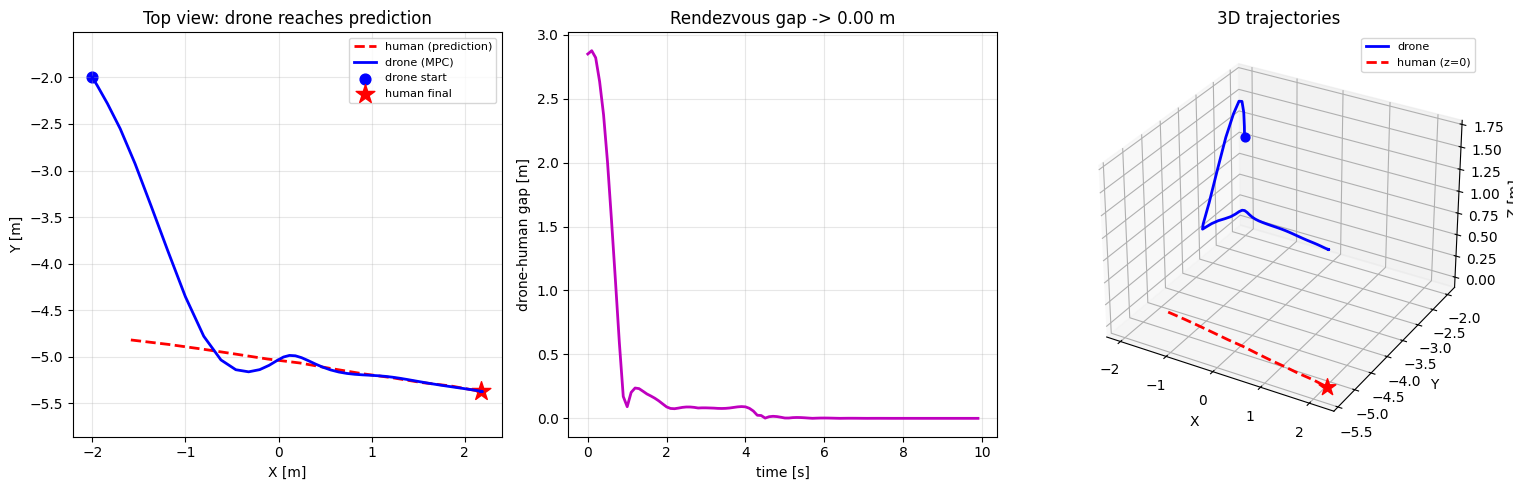

mean solve time : 0.68 ms  (real-time capable)
final gap       : 0.000 m


In [5]:
drone = mpc['drone_path']; human = mpc['human_path']; tt = mpc['time']; gap = mpc['gap']

fig = plt.figure(figsize=(15, 5))

# top view
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(human[:, 0], human[:, 1], 'r--', lw=2, label='human (prediction)')
ax1.plot(drone[:, 0], drone[:, 1], 'b-', lw=2, label='drone (MPC)')
ax1.scatter(drone[0, 0], drone[0, 1], c='blue', marker='o', s=60, label='drone start')
ax1.scatter(human[-1, 0], human[-1, 1], c='red', marker='*', s=200, label='human final')
ax1.set_xlabel('X [m]'); ax1.set_ylabel('Y [m]'); ax1.axis('equal'); ax1.grid(alpha=0.3)
ax1.legend(fontsize=8); ax1.set_title('Top view: drone reaches prediction')

# convergence gap
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(tt, gap, 'm-', lw=2)
ax2.set_xlabel('time [s]'); ax2.set_ylabel('drone-human gap [m]'); ax2.grid(alpha=0.3)
ax2.set_title(f'Rendezvous gap -> {gap[-1]:.2f} m')

# 3D
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
ax3.plot(drone[:, 0], drone[:, 1], drone[:, 2], 'b-', lw=2, label='drone')
ax3.plot(human[:, 0], human[:, 1], human[:, 2], 'r--', lw=2, label='human (z=0)')
ax3.scatter(*drone[0], c='blue', marker='o', s=40)
ax3.scatter(*human[-1], c='red', marker='*', s=160)
ax3.set_xlabel('X'); ax3.set_ylabel('Y'); ax3.set_zlabel('Z [m]'); ax3.legend(fontsize=8)
ax3.set_title('3D trajectories')
plt.tight_layout(); plt.show()

print(f"mean solve time : {mpc['solve_time'].mean()*1000:.2f} ms  (real-time capable)")
print(f"final gap       : {gap[-1]:.3f} m")

## 4. Whole-video sliding-window tracking (receding horizon)

Section 3 used a single frozen prediction.  **Trajectron++ runs as a sliding window over the entire clip** — at every 0.4 s step it observes the last 2.8 s and forecasts the next 4.8 s, giving **83 predictions** across the video (`vio_predict_all.py`).

The MPC then runs as a true **receding-horizon closed loop** (`vio_mpc_rolling.py`): every 0.1 s control step it re-reads the *current* window's prediction as its reference horizon, so the drone continuously chases the human's freshly re-predicted future position rather than a fixed point. Control time pyramid:

| layer | period | meaning |
|-------|--------|---------|
| Trajectron step | 0.4 s | one new sliding-window prediction |
| MPC control step | 0.1 s | 4 updates per prediction |
| MPC horizon | 2.0 s (10 nodes) | look-ahead used in the cost |

**Result.** Over the full timeline the drone locks onto the walking human and holds a steady gap of about **0.5 m** (it starts 4.2 m away). The solver stays around **0.8 ms** per step. The gap *spikes* (right panel) happen in the far / fast-walking segments (≈15–22 s and ≈40–47 s) — exactly where the grazing-ray ground-cast is noisy and the human moves fastest, so the prediction is least accurate. Those are the segments to improve next (range limit, uncertainty-aware MPC)."

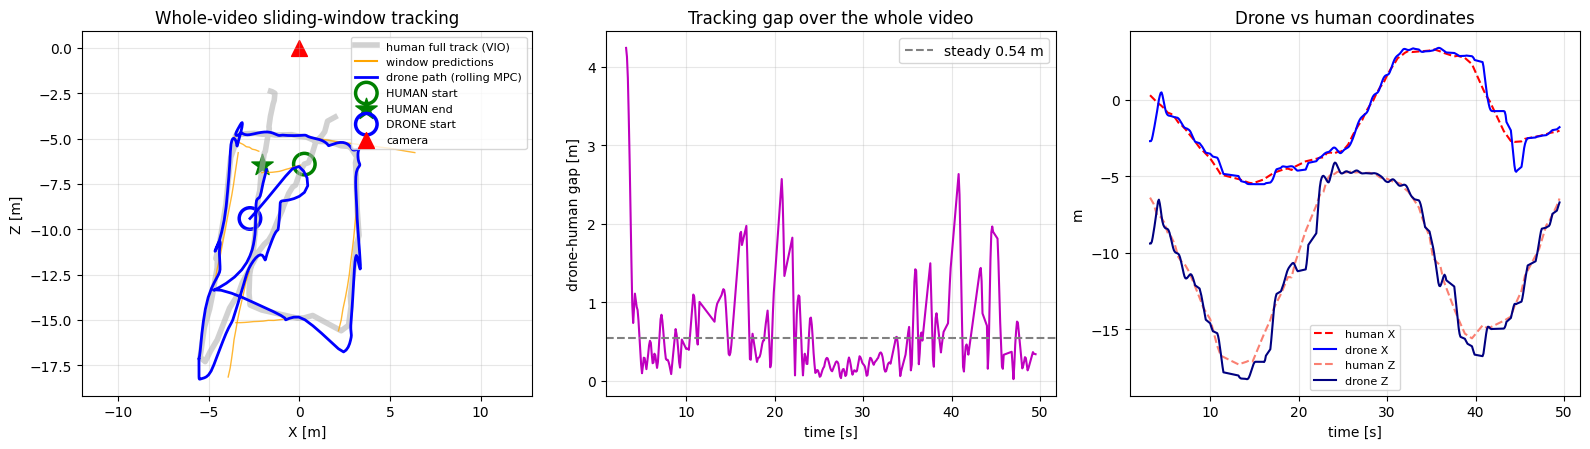

control steps   : 332
mean solve time : 0.52 ms
gap: start 4.24 m -> steady 0.54 m -> final 0.34 m


In [6]:
roll = np.load(os.path.join(HERE, 'vio_mpc_rolling.npz'))
drone, human, rt, rgap = roll['drone_path'], roll['human_path'], roll['time'], roll['gap']
ftrack, wt0, wpred = roll['track_xy'], roll['win_t0'], roll['pred_xy']
steady = rgap[rt > rt[0] + 3].mean()

fig = plt.figure(figsize=(16, 4.6))

ax = fig.add_subplot(1, 3, 1)
ax.plot(ftrack[:, 0], ftrack[:, 1], color='0.7', lw=4, alpha=0.6, label='human full track (VIO)')
for w in range(0, len(wt0), 12):
    ax.plot(wpred[w][:, 0], wpred[w][:, 1], '-', color='orange', lw=1, alpha=0.8)
ax.plot([], [], '-', color='orange', label='window predictions')
ax.plot(drone[:, 0], drone[:, 1], 'b-', lw=2, label='drone path (rolling MPC)')
ax.scatter(human[0, 0], human[0, 1], facecolors='none', edgecolors='green', s=240, lw=2.5, label='HUMAN start')
ax.scatter(human[-1, 0], human[-1, 1], c='green', marker='*', s=260, label='HUMAN end')
ax.scatter(drone[0, 0], drone[0, 1], facecolors='none', edgecolors='blue', s=240, lw=2.5, label='DRONE start')
ax.scatter([0], [0], c='red', marker='^', s=130, label='camera')
ax.axis('equal'); ax.grid(alpha=.3); ax.legend(fontsize=8, loc='upper right')
ax.set_xlabel('X [m]'); ax.set_ylabel('Z [m]'); ax.set_title('Whole-video sliding-window tracking')

ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(rt, rgap, 'm-')
ax2.axhline(steady, ls='--', color='gray', label=f'steady {steady:.2f} m')
ax2.set_xlabel('time [s]'); ax2.set_ylabel('drone-human gap [m]'); ax2.grid(alpha=.3)
ax2.legend(); ax2.set_title('Tracking gap over the whole video')

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(rt, human[:, 0], 'r--', label='human X'); ax3.plot(rt, drone[:, 0], 'b-', label='drone X')
ax3.plot(rt, human[:, 1], color='salmon', ls='--', label='human Z'); ax3.plot(rt, drone[:, 1], color='navy', label='drone Z')
ax3.set_xlabel('time [s]'); ax3.set_ylabel('m'); ax3.grid(alpha=.3); ax3.legend(fontsize=8)
ax3.set_title('Drone vs human coordinates')
plt.tight_layout(); plt.show()

mean_ms = roll['solve_time'].mean() * 1000
print(f'control steps   : {len(drone)}')
print(f'mean solve time : {mean_ms:.2f} ms')
print(f'gap: start {rgap[0]:.2f} m -> steady {steady:.2f} m -> final {rgap[-1]:.2f} m')

### Animation & what the drone actually does

The animation below (`vio_tracking.gif`) shows the whole run. **Left** = top-down ground view: the human (green) walks the grey track, the drone (blue square) follows, and the orange curve is the prediction horizon the drone is currently chasing. **Right** = side view: it makes clear that the **drone flies at $z=1.5$ m, i.e. ~1.5 m *above* the human** (the magenta line is the vertical link) — it does **not** run into the person. The residual horizontal gap (~0.5 m on average) is just the lag of chasing a moving target.

If we want the drone to keep a deliberate standoff (e.g. follow 2 m behind or hover 3 m above instead of directly overhead), we add a fixed offset to the reference $P_j$ — a one-line change in the cost reference.

**Is the sliding window the right idea?** Yes. It is exactly how prediction works online on a real drone: at every step you observe the most recent history and re-forecast the future, then re-plan. A single frozen prediction would go stale as soon as the human changed direction; re-predicting every 0.4 s keeps the reference fresh and is the standard receding-horizon prediction+control setup in the literature (refs above)."

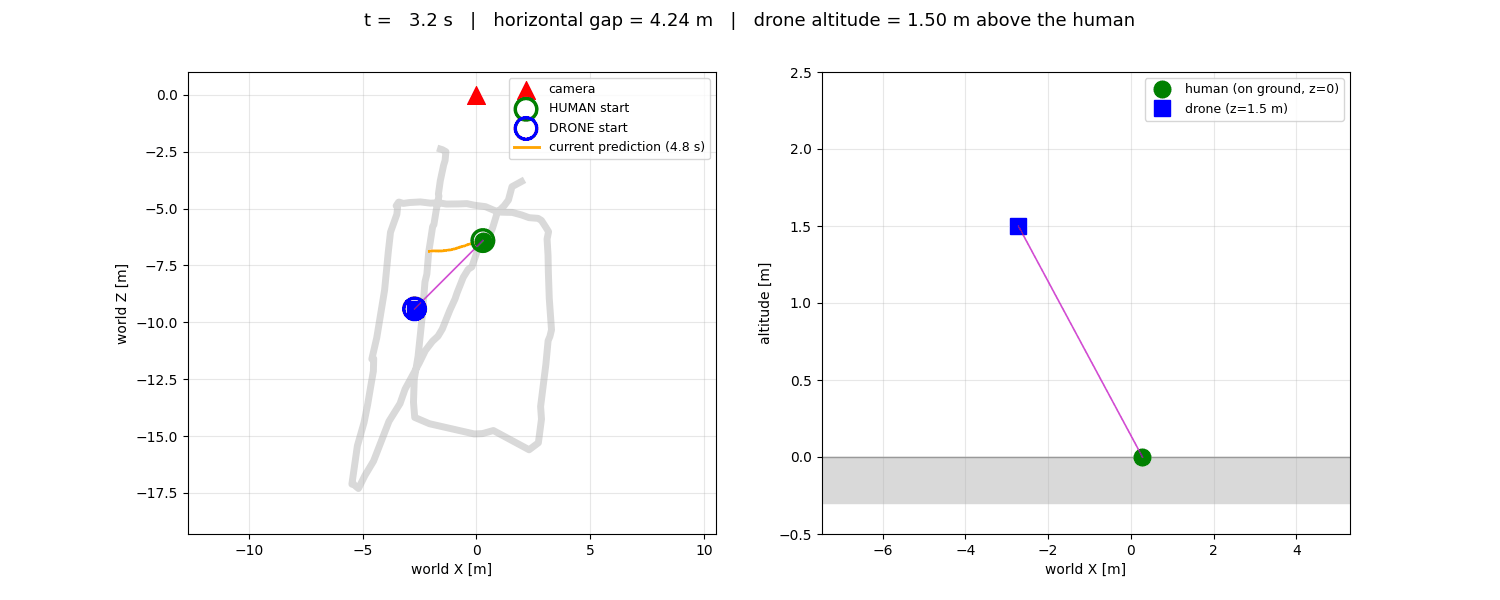

In [7]:
from IPython.display import Image as IPyImage
IPyImage(filename=os.path.join(HERE, 'vio_tracking.gif'))

## 5. Summary & next steps

**What works end-to-end now.**
1. A hand-held phone clip + ARKit VIO gives a **metric, gravity-aligned** camera pose without any drone or measured court geometry.
2. YOLO foot pixels are **ray-cast** to the floor plane to recover the human's metric ground track (a clean, realistic walking path).
3. The **ETH base Trajectron++ (100 ep)** predicts the human's next 4.8 s; near-range accuracy is ADE 0.26 m / FDE 0.53 m.
4. The prediction is the **reference of the NMPC** (acados); for a single window the drone converges to the human's predicted position (final gap $\approx$ 0 m, solve time < 1 ms).
5. Running it as a **sliding-window receding-horizon loop over the whole video** (83 re-predictions), the drone continuously follows the walking human at a steady $\approx$ 0.5 m gap.


- Long-range ray-cast is noisy (grazing rays). Restrict the working range, or use the IMU pitch + a richer plane model. This is the main driver of the high dataset-mean ADE.
- Feed the **GMM covariance** into the MPC as a chance constraint (refs 3, 5) instead of only tracking the mean.
- Fine-tune / compare predictors (Trajectron++ vs. simpler constant-velocity / Social-LSTM baselines) on more VIO-derived tracks.


**Files produced by this pipeline (in `vio_pipeline/`).** `vio_yolo_detect.py` &rarr; `vio_foot_pixels.csv`, `vio_overlay.mp4`; `vio_raycast.py` &rarr; `vio_human_trajectory_metres.csv`; `vio_trajectron_predict.py` &rarr; `vio_human_pred*.{csv,npy,json}`; `cuav_nmpc/main_human_target.py --pred ...` &rarr; `vio_mpc_result.npz`.